In [1]:
import lightkurve as lk
import numpy as np

from matplotlib import pyplot as plt
from transitleastsquares import transitleastsquares, transit_mask, cleaned_array

%matplotlib inline

/opt/miniconda3/envs/allesfitter/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
multiple_sectors = True

In [3]:
search_result = lk.search_lightcurve('Kepler 51', author='Kepler')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 01,2009,Kepler,1800,kplr011773022,0.0
1,Kepler Quarter 02,2009,Kepler,1800,kplr011773022,0.0
2,Kepler Quarter 03,2009,Kepler,1800,kplr011773022,0.0
3,Kepler Quarter 04,2010,Kepler,1800,kplr011773022,0.0
4,Kepler Quarter 05,2010,Kepler,1800,kplr011773022,0.0
5,Kepler Quarter 06,2010,Kepler,1800,kplr011773022,0.0
6,Kepler Quarter 07,2010,Kepler,1800,kplr011773022,0.0
7,Kepler Quarter 08,2011,Kepler,1800,kplr011773022,0.0
8,Kepler Quarter 09,2011,Kepler,1800,kplr011773022,0.0


In [4]:
# [3, 4, 5, 6, 7, 8, 9, 21, 22, 23, 24, 33]
if multiple_sectors:
    lc_collection = search_result[[3, 4, 5, 6, 7, 8, 9, 21, 22, 23, 24, 33]].download_all(quality_bitmask='default')
    print(lc_collection)
else:
    lc = search_result[0].download(quality_bitmask='default')
    print(lc)

LightCurveCollection of 12 objects:
    0: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=4 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    1: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=5 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    2: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=6 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    3: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=7 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    4: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=8 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    5: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=9 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    6: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=10 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    7: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=13 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    8: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=12 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    9: <KeplerLightCurve LABEL="KIC 11773022" QUARTER=14 AUTHOR=Kepler FLUX_ORIGIN=pdcsap_flux>
    10: <K

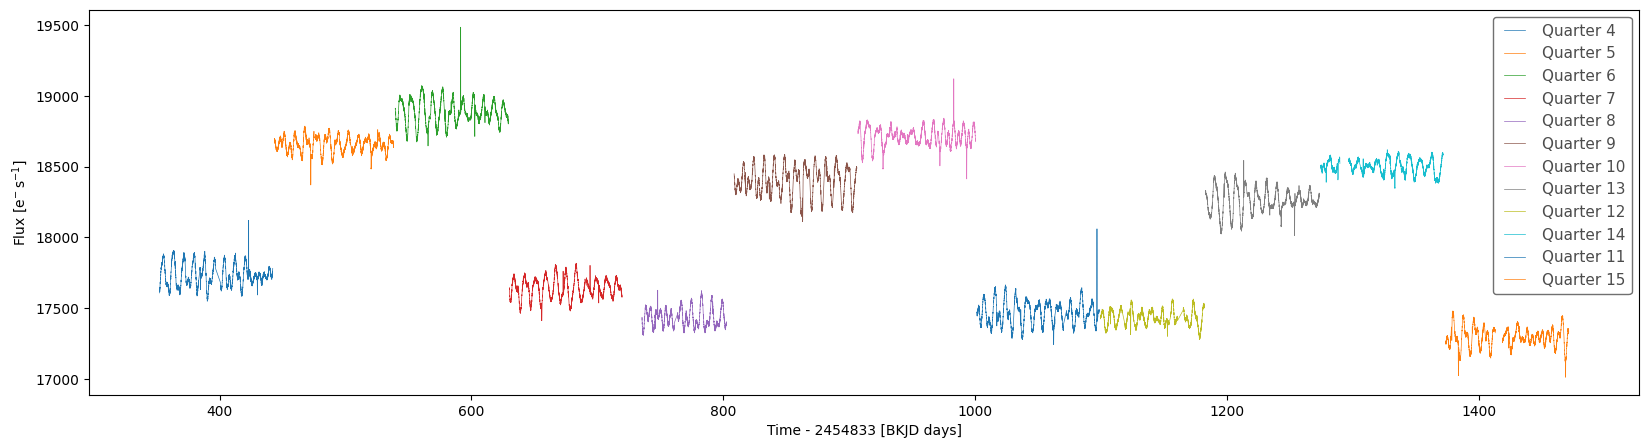

In [5]:
# Create a larger figure for clarity
fig, ax = plt.subplots(figsize=(20,5))

# Plot the single light curve or light-curve collection
for i in range(len(lc_collection)):
    lc_collection[i].plot(ax=ax, label=f'Quarter {lc_collection[i].quarter}');

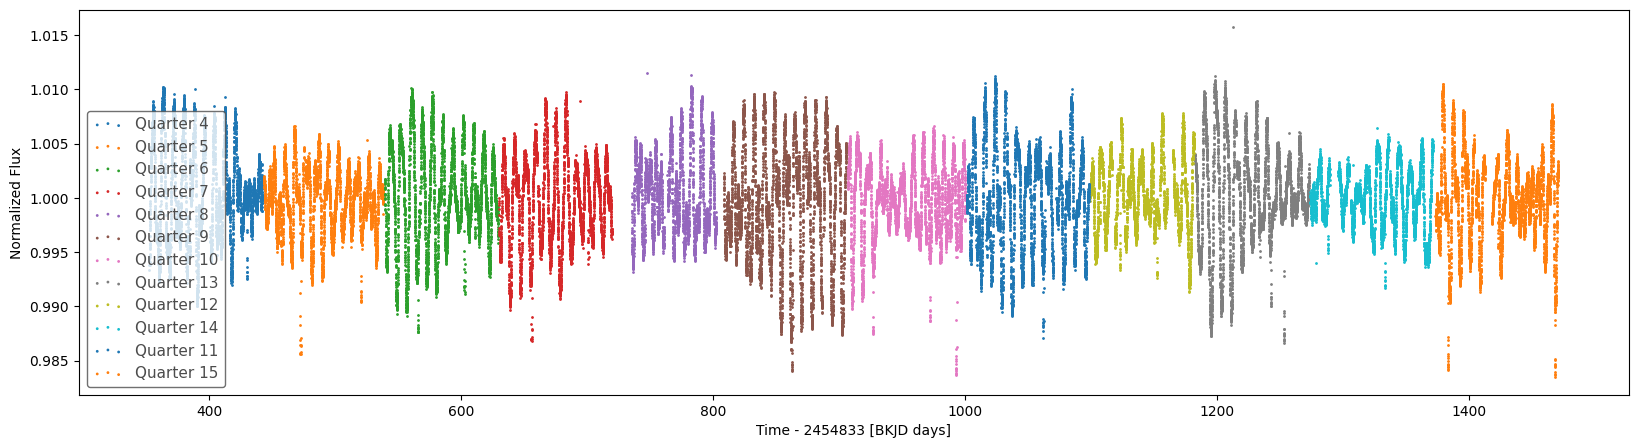

In [6]:
fig, ax1 = plt.subplots(figsize=(20,5))
for i in range(len(lc_collection)):
    lc_collection[i].remove_outliers().normalize().scatter(ax=ax1, label=f'Quarter {lc_collection[i].quarter}');
lc = lc_collection.stitch().remove_outliers().normalize()

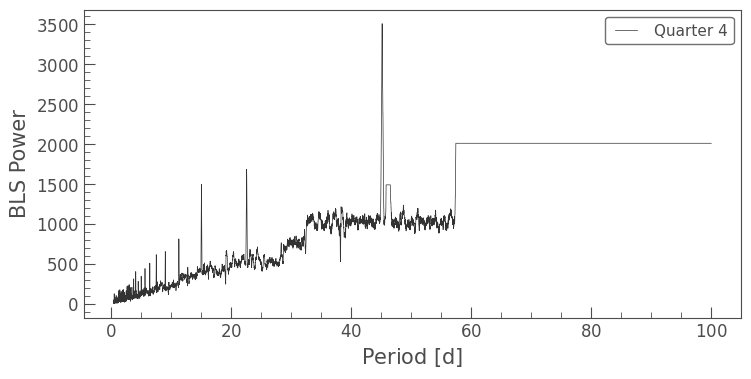

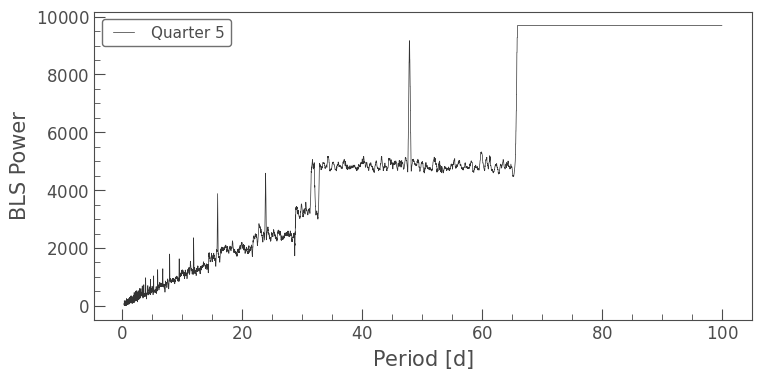

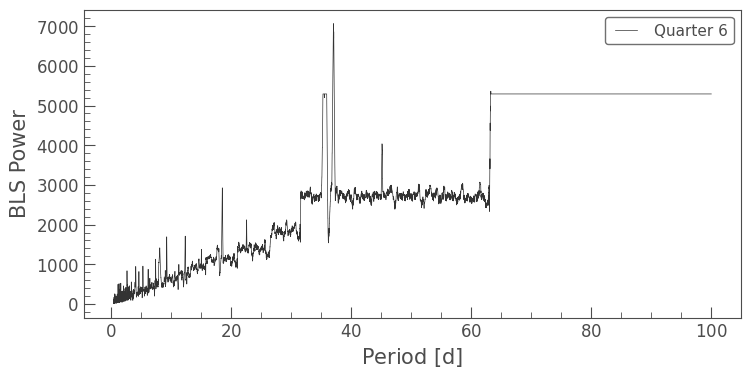

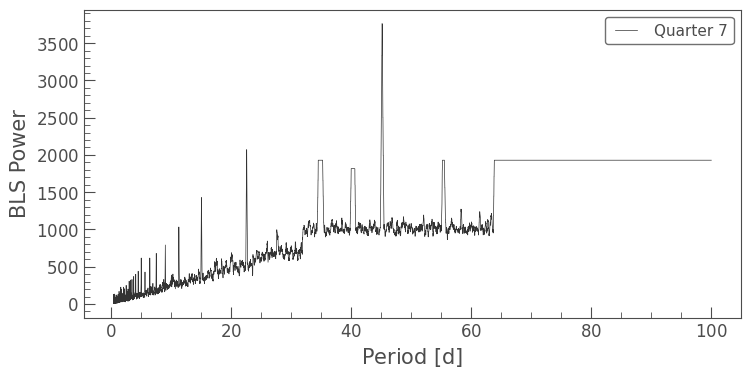

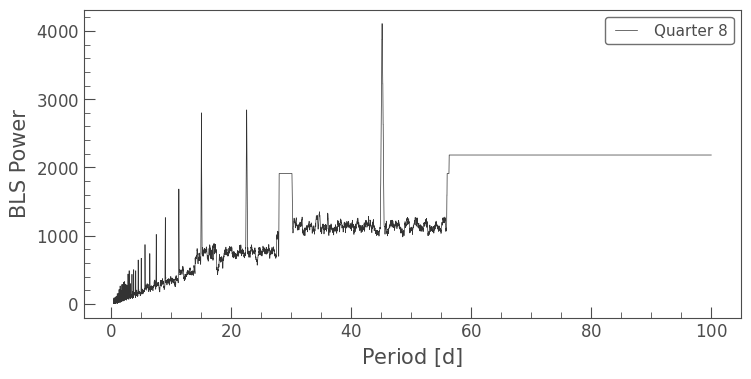

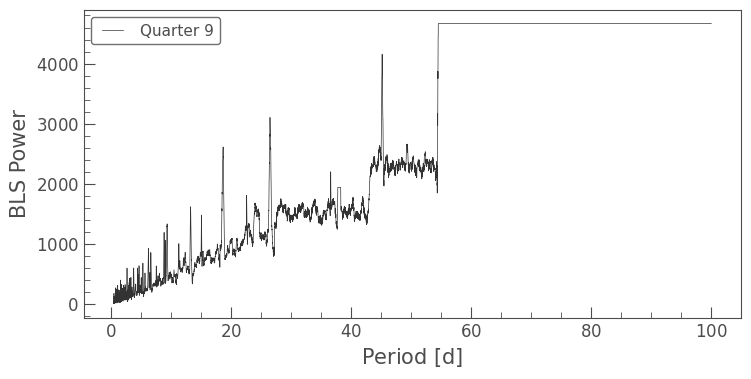

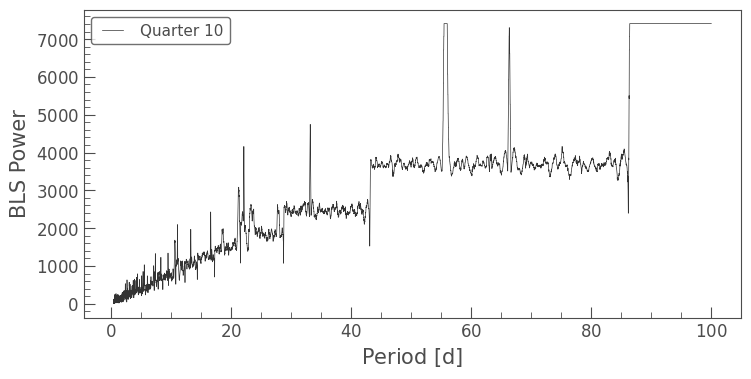

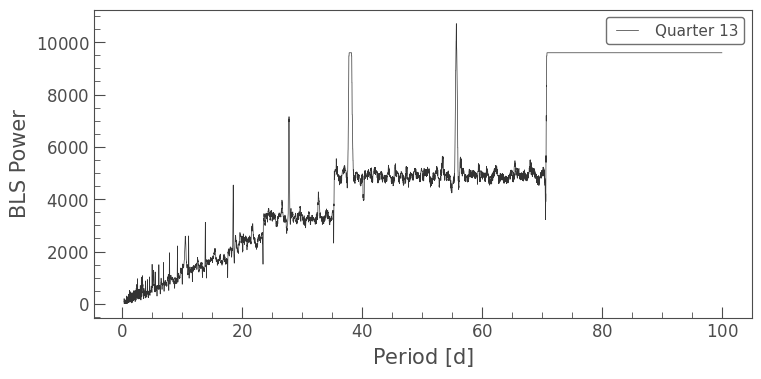

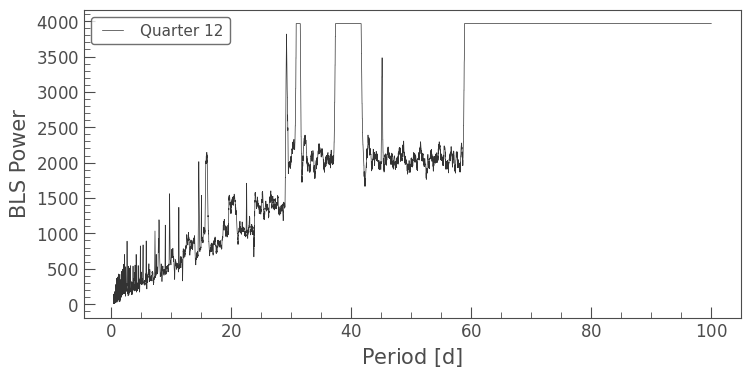

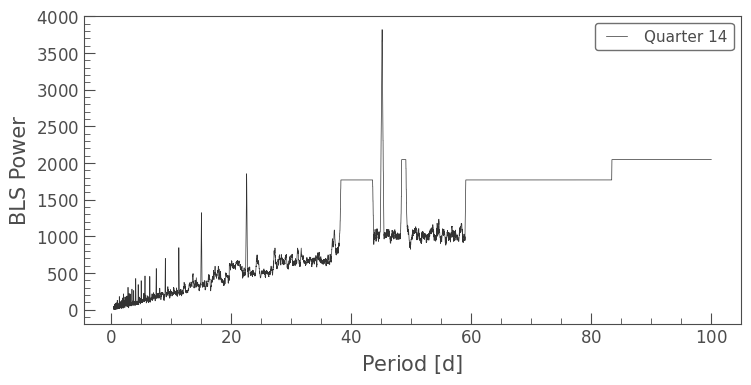

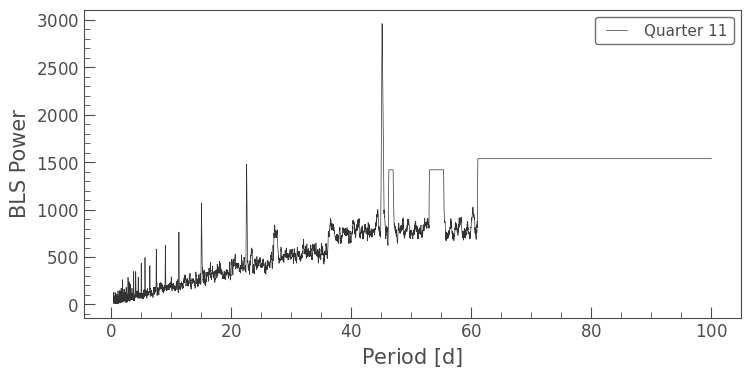

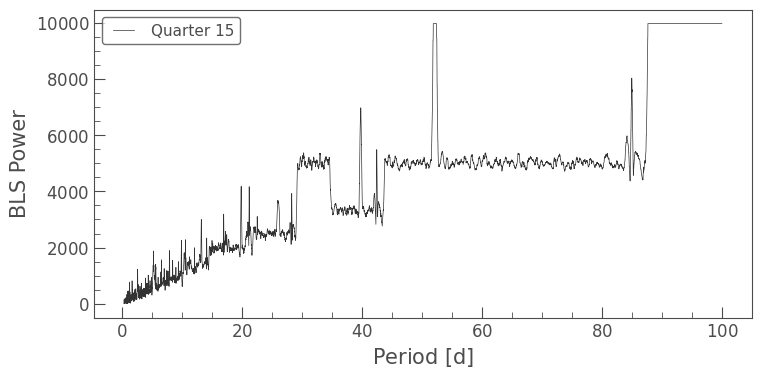

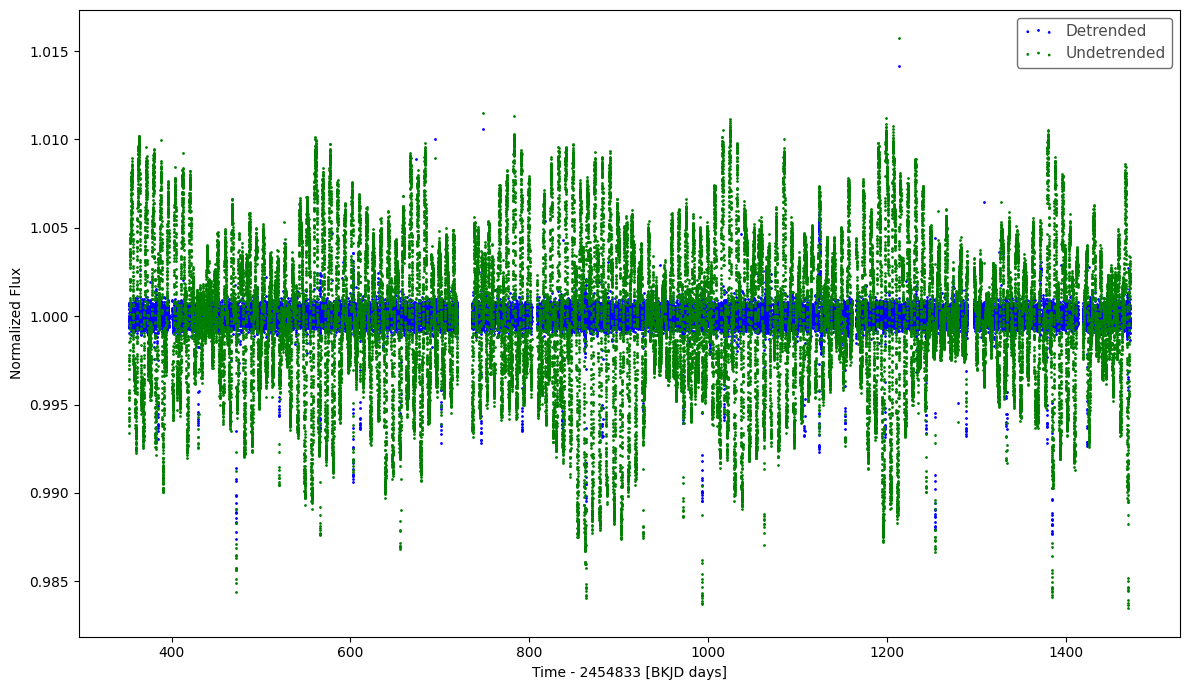

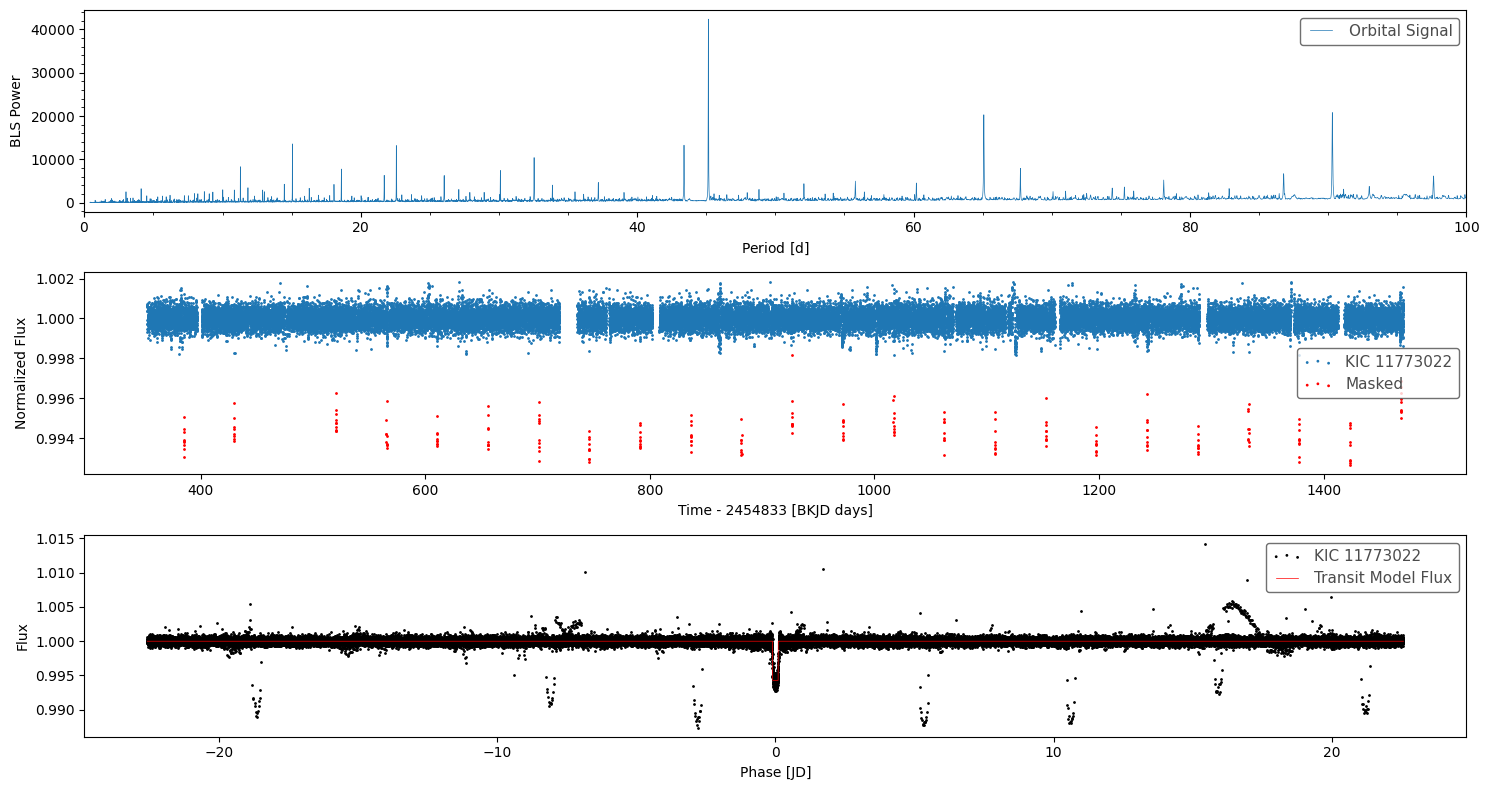

45.15475547554755 d


In [7]:
from lightkurve.periodogram import Periodogram
from lightkurve import LightCurveCollection
from astropy.units import Quantity

# Create array of periods to search
sup_lim = 100
periods = np.linspace(0.4, sup_lim, 10000)
stacked_powers = []
for i in range(len(lc_collection)):
    # Create a BLSPeriodogram for each light-curve object
    lci_flatten = lc_collection[i].flatten()
    # Boz-least Square Periodogram
    pedogram_flatten = lci_flatten.to_periodogram(method='bls', period=periods, frequency_factor=2000)
    stacked_powers.append(np.asarray(pedogram_flatten.power))
    # Lomb-Scargle Periodogram
    # pedogram_flatten = lci_flatten.to_periodogram(method='ls', period=periods, oversample_factor=2, nterms = 2)#, frequency_factor=1000)
    pedogram_flatten.plot(label=f'Quarter {lc_collection[i].quarter}');

lc_flatten = lc.flatten()

# Create a final BLSPeriodogram for the total stitched light curve
pedogram_orbital_b = lc_flatten.to_periodogram(method='bls', period=periods, frequency_factor=2000)
# Create a final GLSPeriodogram for the total stitched light curve
# pedogram_orbital = lc_flatten.to_periodogram(method='ls', period=periods, oversample_factor=2, nterms=2)#, frequency_factor=1000)
# pedogram_orbital.plot();

fig, ax = plt.subplots(1, 1, figsize=(12,7))
flatten = lc_flatten.scatter(ax=ax, c='b', label='Detrended');
no_flatten = lc.scatter(ax=ax, c='g', label='Undetrended');

fig.tight_layout()
plt.show()
plt.close();

fig, ax = plt.subplots(3, 1, figsize=(15,8))
ax_orb = pedogram_orbital_b.plot(ax=ax[0], label = 'Orbital Signal');
ax_orb.set_xlim(0.0, sup_lim);

planet_b_period = pedogram_orbital_b.period_at_max_power
planet_b_t0 = pedogram_orbital_b.transit_time_at_max_power
planet_b_dur = pedogram_orbital_b.duration_at_max_power

transit_model_b = pedogram_orbital_b.get_transit_model(period=planet_b_period, duration=planet_b_dur, transit_time=planet_b_t0)
transit_stats_b = pedogram_orbital_b.compute_stats(period=planet_b_period, duration=planet_b_dur, transit_time=planet_b_t0)

# Create a cadence mask using the BLS parameters
planet_b_mask = pedogram_orbital_b.get_transit_mask(period=planet_b_period, transit_time=planet_b_t0, duration=planet_b_dur)
masked_lc = lc[~planet_b_mask]
masked_lc_flatten = lc_flatten[~planet_b_mask]
masked_lc_flatten.remove_outliers().scatter(ax=ax[1]);
lc_flatten[planet_b_mask].remove_outliers().scatter(ax=ax[1], c='r', label='Masked');

lc_flatten.fold(period=planet_b_period, epoch_time=planet_b_t0).scatter(ax=ax[2], c='k')
transit_model_b.fold(period=planet_b_period, epoch_time=planet_b_t0).plot(ax=ax[2], c='r')
min_time = lc.time[np.where(lc.flux == lc.flux.min())[0]]
max_time = lc.time[np.where(lc.flux == lc.flux.max())[0]]
# ax.set_xlim(-0.35, 0.35);
# ax.set_xlim(min_time.jd, max_time.jd);

fig.tight_layout()
plt.show()
plt.close();

print(planet_b_period)

In [ ]:
fig, ax = plt.subplots(figsize=(20,5))

rot_sup_lim = 10
periods = np.linspace(0.4, rot_sup_lim, 3000)
pedogram_rotational = masked_lc.to_periodogram(ls_method='chi2', method='ls', period=periods)

ax_rot = pedogram_rotational.plot(ax=ax, label = 'Rotational Signal?');
ax_rot.set_xlim(0.0, rot_sup_lim);

plt.show();

In [ ]:
rot_period = pedogram_rotational.period_at_max_power
rot_period

In [ ]:
ax = lc_flatten.fold(period=rot_period, epoch_time=planet_b_t0).scatter()

In [ ]:
sup_lim = 150
periods = np.linspace(0.4, sup_lim, 10000)
pedogram_orbital_d = lc_flatten[~planet_b_mask].to_periodogram(method='bls', period=periods, frequency_factor=2000)
# Create a final GLSPeriodogram for the total stitched light curve
# pedogram_orbital = lc_flatten.to_periodogram(method='ls', period=periods, oversample_factor=2, nterms=2)#, frequency_factor=1000)
# pedogram_orbital.plot();

fig, ax = plt.subplots(3, 1, figsize=(15,8))

ax_orb = pedogram_orbital_d.plot(ax=ax[0], label = 'Orbital Signal');
ax_orb.set_xlim(0.0, sup_lim);

planet_d_period = pedogram_orbital_d.period_at_max_power
planet_d_t0 = pedogram_orbital_d.transit_time_at_max_power
planet_d_dur = pedogram_orbital_d.duration_at_max_power

transit_model_d = pedogram_orbital_d.get_transit_model(period=planet_d_period, duration=planet_d_dur, transit_time=planet_d_t0)
transit_stats_d = pedogram_orbital_d.compute_stats(period=planet_d_period, duration=planet_d_dur, transit_time=planet_d_t0)

# Create a cadence mask using the BLS parameters
planet_d_mask = pedogram_orbital_d.get_transit_mask(period=planet_d_period, transit_time=planet_d_t0, duration=planet_d_dur)
lc_d = masked_lc[~planet_d_mask]
lc_flatten_d = masked_lc_flatten[~planet_d_mask]
lc_flatten_d.remove_outliers().scatter(ax=ax[1]);
masked_lc_flatten[planet_d_mask].remove_outliers().scatter(ax=ax[1], c='r', label='Masked');

masked_lc_flatten.fold(period=planet_d_period, epoch_time=planet_d_t0).scatter(ax=ax[2], c='k')
transit_model_d.fold(period=planet_d_period, epoch_time=planet_d_t0).plot(ax=ax[2], c='r')
min_time = lc.time[np.where(lc.flux == lc.flux.min())[0]]
max_time = lc.time[np.where(lc.flux == lc.flux.max())[0]]
# ax.set_xlim(-0.35, 0.35);
# ax.set_xlim(min_time.jd, max_time.jd);

fig.tight_layout()

print(planet_d_period)


In [ ]:
sup_lim = 100
periods = np.linspace(0.4, sup_lim, 10000)

pedogram_orbital_c = lc_flatten_d.to_periodogram(method='bls', period=periods, frequency_factor=2000)
# Create a final GLSPeriodogram for the total stitched light curve
# pedogram_orbital = lc_flatten.to_periodogram(method='ls', period=periods, oversample_factor=2, nterms=2)#, frequency_factor=1000)
# pedogram_orbital.plot();

fig, ax = plt.subplots(3, 1, figsize=(15,8))

ax_orb = pedogram_orbital_c.plot(ax=ax[0], label = 'Orbital Signal');
ax_orb.set_xlim(0.0, sup_lim);

planet_period = pedogram_orbital_c.period_at_max_power
planet_t0 = pedogram_orbital_c.transit_time_at_max_power
planet_dur = pedogram_orbital_c.duration_at_max_power

# transit_model_b = pedogram_orbital_b.get_transit_model(period=planet_b_period, duration=planet_b_dur, transit_time=planet_b_t0)
# transit_stats_b = pedogram_orbital_b.compute_stats(period=planet_b_period, duration=planet_b_dur, transit_time=planet_b_t0)

# # Create a cadence mask using the BLS parameters
# planet_b_mask = pedogram_orbital_b.get_transit_mask(period=planet_b_period, transit_time=planet_b_t0, duration=planet_b_dur)
# lc_b = masked_lc[~planet_b_mask]
# lc_flatten_b = masked_lc_flatten[~planet_b_mask]
# lc_flatten_b.remove_outliers().scatter(ax=ax[1]);
# masked_lc_flatten[planet_b_mask].remove_outliers().scatter(ax=ax[1], c='r', label='Masked');

# masked_lc_flatten.fold(period=planet_b_period, epoch_time=planet_b_t0).scatter(ax=ax[2], c='k')
# transit_model_b.fold(period=planet_b_period, epoch_time=planet_b_t0).plot(ax=ax[2], c='r')
# min_time = lc.time[np.where(lc.flux == lc.flux.min())[0]]
# max_time = lc.time[np.where(lc.flux == lc.flux.max())[0]]
# # ax.set_xlim(-0.35, 0.35);
# # ax.set_xlim(min_time.jd, max_time.jd);

fig.tight_layout()

print(planet_period)


Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 64 durations
Searching 50144 data points, 141573 periods from 0.602 to 559.37 days
Using all 8 CPU threads


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141573/141573 periods | 31:10<00:00


Searching for best T0 for period 130.17166 days


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 43603/43603 [00:16<00:00, 2603.59it/s]


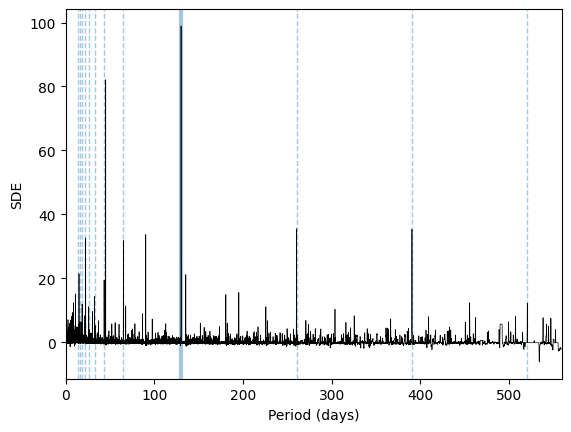

In [8]:
time = lc_flatten.time.value
flux = lc_flatten.flux.value
flux_err = lc_flatten.flux_err.value

model = transitleastsquares(time, flux)
results = model.power()

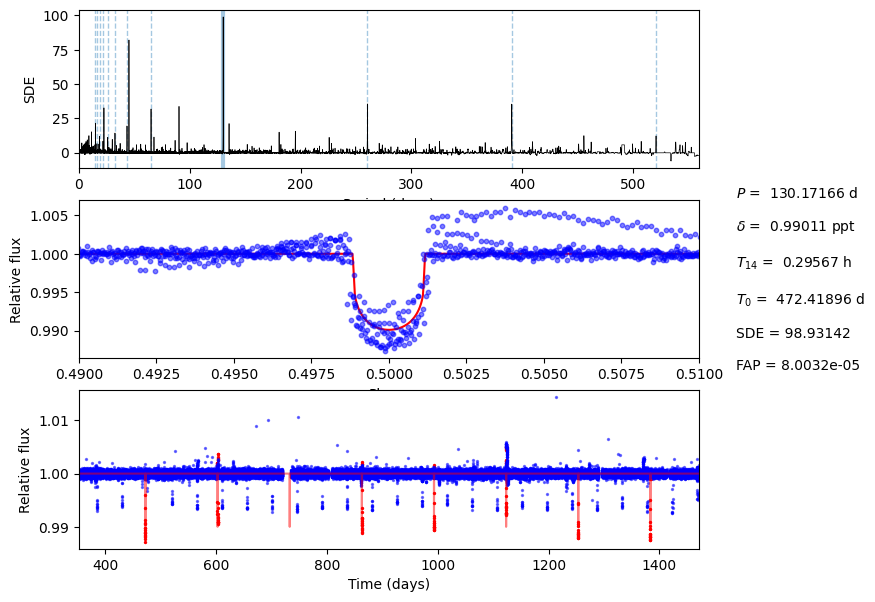

In [84]:
fig, ax = plt.subplots(3, 1, figsize=(8, 7))

ax[0].axvline(results.period, alpha=0.4, lw=3)
plt.xlim(np.min(results.periods), np.max(results.periods))
for n in range(2, 10):
    ax[0].axvline(n*results.period, alpha=0.4, lw=1, linestyle="dashed")
    ax[0].axvline(results.period / n, alpha=0.4, lw=1, linestyle="dashed")
ax[0].set_ylabel(r'SDE')
ax[0].set_xlabel('Period (days)')
ax[0].plot(results.periods, results.power, color='black', lw=0.5)
ax[0].set_xlim(0, max(results.periods));

ax[1].plot(results.model_folded_phase, results.model_folded_model, color='red')
ax[1].scatter(results.folded_phase, results.folded_y, color='blue', s=10, alpha=0.5, zorder=2)
ax[1].set_xlim(0.49, 0.51)
ax[1].set_ylim(min(results.folded_y) - 0.001, 1.007)
ax[1].set_xlabel('Phase')
ax[1].set_ylabel('Relative flux');

intransit = transit_mask(time, results.period, 2 * results.duration, results.T0)

ax[2].scatter(time[intransit], flux[intransit], color='red', s=2,zorder=0)
ax[2].scatter(time[~intransit], flux[~intransit], color='blue', alpha=0.5, s=2, zorder=0)
ax[2].plot(results.model_lightcurve_time, results.model_lightcurve_model, alpha=0.5, color='red', zorder=1)
ax[1].text(
    1.06,
    0.5,
    f'$P$ = {results.period: .5f} d\n\n' 
    f'$\delta$ = {results.depth: .5f} ppt\n\n'
    '$T_{14}$ = 'f'{results.duration: .5f} h\n\n'
    f'$T_0$ = {results.T0: .5f} d\n\n'
    f'SDE = {results.SDE:.5f}\n\n'
    f'FAP = {results.FAP}',
    transform=ax[1].transAxes,
    va='center'
)

ax[2].set_xlim(min(time), max(time))
# ax[2].ylim(0.9985, 1.0003)
ax[2].set_xlabel('Time (days)')
ax[2].set_ylabel('Relative flux');
# plt.tight_layout()

In [10]:
y_second_run = flux[~intransit]
y_second_run_err = flux_err[~intransit]
t_second_run = time[~intransit]
t_second_run, y_second_run = cleaned_array(t_second_run, y_second_run)

model_second_run = transitleastsquares(t_second_run, y_second_run)
results_second_run = model_second_run.power()

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 64 durations
Searching 49947 data points, 141573 periods from 0.602 to 559.37 days
Using all 8 CPU threads


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141573/141573 periods | 2:14:28<00:00


Searching for best T0 for period 45.15647 days


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18430/18430 [00:09<00:00, 1929.96it/s]


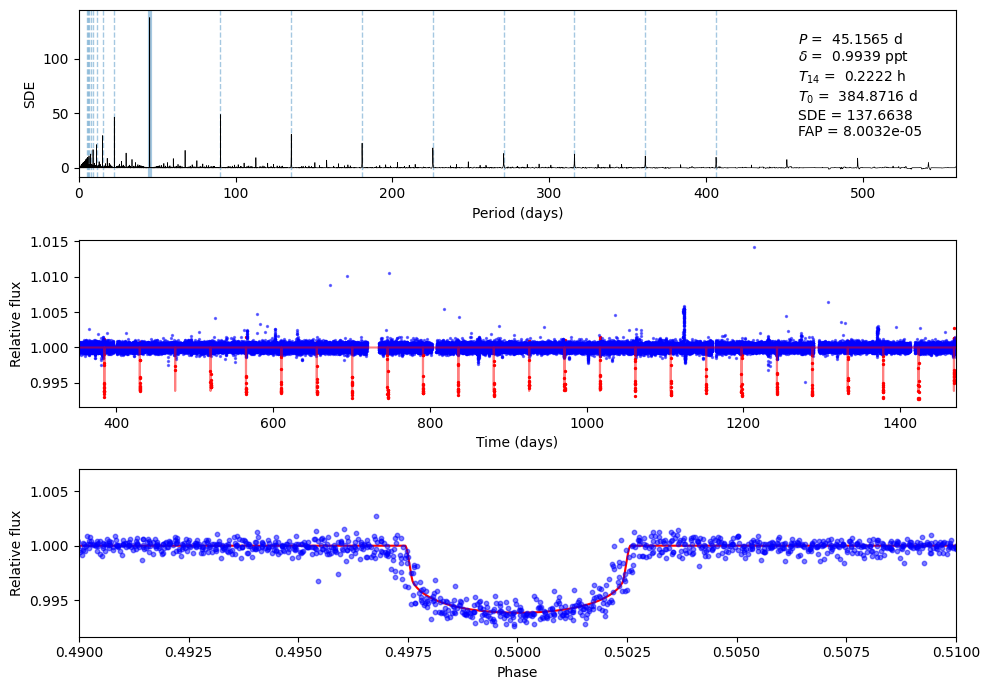

In [118]:
fig, ax = plt.subplots(3, 1, figsize=(10, 7))

ax[0].axvline(results_second_run.period, alpha=0.4, lw=3)
plt.xlim(np.min(results_second_run.periods), np.max(results_second_run.periods))
for n in range(2, 10):
    ax[0].axvline(n*results_second_run.period, alpha=0.4, lw=1, linestyle="dashed")
    ax[0].axvline(results_second_run.period / n, alpha=0.4, lw=1, linestyle="dashed")
ax[0].set_ylabel(r'SDE')
ax[0].set_xlabel('Period (days)')
ax[0].plot(results_second_run.periods, results_second_run.power, color='black', lw=0.5)
ax[0].set_xlim(0, max(results_second_run.periods));

ax[1].scatter(t_second_run[intransit], y_second_run[intransit], color='red', s=2,zorder=0)
ax[1].scatter(t_second_run[~intransit], y_second_run[~intransit], color='blue', alpha=0.5, s=2, zorder=0)
ax[1].plot(results_second_run.model_lightcurve_time, results_second_run.model_lightcurve_model, alpha=0.5, color='red', zorder=1)

ax[1].set_xlim(min(time), max(time))
# ax[1].ylim(0.9985, 1.0003)
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('Relative flux');

ax[2].plot(results_second_run.model_folded_phase, results_second_run.model_folded_model, color='red')
ax[2].scatter(results_second_run.folded_phase, results_second_run.folded_y, color='blue', s=10, alpha=0.5, zorder=2)
ax[2].set_xlim(0.49, 0.51)
ax[2].set_ylim(min(results_second_run.folded_y) - 0.001, 1.007)
ax[2].set_xlabel('Phase')
ax[2].set_ylabel('Relative flux');

intransit = transit_mask(t_second_run, results_second_run.period, 2 * results_second_run.duration, results_second_run.T0)



fig.tight_layout()

ax[1].text(
    0.82,
    0.55,
    f'$P$ = {results_second_run.period: .4f} d\n' 
    f'$\delta$ = {results_second_run.depth: .4f} ppt\n'
    '$T_{14}$ = 'f'{results_second_run.duration: .4f} h\n'
    f'$T_0$ = {results_second_run.T0: .4f} d\n'
    f'SDE = {results_second_run.SDE:.4f}\n'
    f'FAP = {results_second_run.FAP}',
    transform=ax[0].transAxes,
    va='center'
)
fig.savefig('toi-561b.png', dpi=300)

In [13]:
y_third_run = y_second_run[~intransit]
t_third_run = t_second_run[~intransit]
t_third_run, y_third_run = cleaned_array(t_third_run, y_third_run)

model_third_run = transitleastsquares(t_third_run, y_third_run)
results_third_run = model_third_run.power()

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 64 durations
Searching 49428 data points, 141573 periods from 0.602 to 559.37 days
Using all 8 CPU threads


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141573/141573 periods | 3:13:24<00:00


Searching for best T0 for period 85.31911 days


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49428/49428 [00:25<00:00, 1967.03it/s]


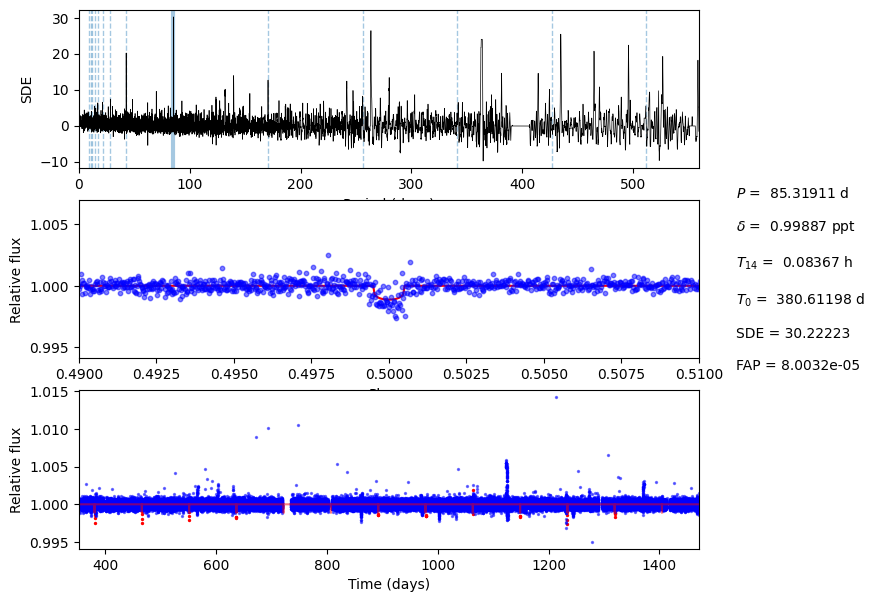

In [87]:
fig, ax = plt.subplots(3, 1, figsize=(8, 7))

ax[0].axvline(results_third_run.period, alpha=0.4, lw=3)
plt.xlim(np.min(results_third_run.periods), np.max(results_third_run.periods))
for n in range(2, 10):
    ax[0].axvline(n*results_third_run.period, alpha=0.4, lw=1, linestyle="dashed")
    ax[0].axvline(results_third_run.period / n, alpha=0.4, lw=1, linestyle="dashed")
ax[0].set_ylabel(r'SDE')
ax[0].set_xlabel('Period (days)')
ax[0].plot(results_third_run.periods, results_third_run.power, color='black', lw=0.5)
ax[0].set_xlim(0, max(results_third_run.periods));

ax[1].plot(results_third_run.model_folded_phase, results_third_run.model_folded_model, color='red')
ax[1].scatter(results_third_run.folded_phase, results_third_run.folded_y, color='blue', s=10, alpha=0.5, zorder=2)
ax[1].set_xlim(0.49, 0.51)
ax[1].set_ylim(min(results_third_run.folded_y) - 0.001, 1.007)
ax[1].set_xlabel('Phase')
ax[1].set_ylabel('Relative flux');

intransit = transit_mask(t_third_run, results_third_run.period, 2 * results_third_run.duration, results_third_run.T0)

ax[2].scatter(t_third_run[intransit], y_third_run[intransit], color='red', s=2,zorder=0)
ax[2].scatter(t_third_run[~intransit], y_third_run[~intransit], color='blue', alpha=0.5, s=2, zorder=0)
ax[2].plot(results_third_run.model_lightcurve_time, results_third_run.model_lightcurve_model, alpha=0.5, color='red', zorder=1)
ax[1].text(
    1.06,
    0.5,
    f'$P$ = {results_third_run.period: .5f} d\n\n' 
    f'$\delta$ = {results_third_run.depth: .5f} ppt\n\n'
    '$T_{14}$ = 'f'{results_third_run.duration: .5f} h\n\n'
    f'$T_0$ = {results_third_run.T0: .5f} d\n\n'
    f'SDE = {results_third_run.SDE:.5f}\n\n'
    f'FAP = {results_third_run.FAP}',
    transform=ax[1].transAxes,
    va='center'
)

ax[2].set_xlim(min(time), max(time))
# ax[2].ylim(0.9985, 1.0003)
ax[2].set_xlabel('Time (days)')
ax[2].set_ylabel('Relative flux');
# plt.tight_layout()

In [17]:
y_fourth_run = y_third_run[~intransit]
t_fourth_run = t_third_run[~intransit]
t_fourth_run, y_fourth_run = cleaned_array(t_fourth_run, y_fourth_run)


model_fourth_run = transitleastsquares(t_fourth_run, y_fourth_run)
results_fourth_run = model_fourth_run.power()

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 64 durations
Searching 49347 data points, 141573 periods from 0.602 to 559.37 days
Using all 8 CPU threads


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141573/141573 periods | 14:29<00:00


Searching for best T0 for period 263.46714 days


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49347/49347 [00:18<00:00, 2686.13it/s]


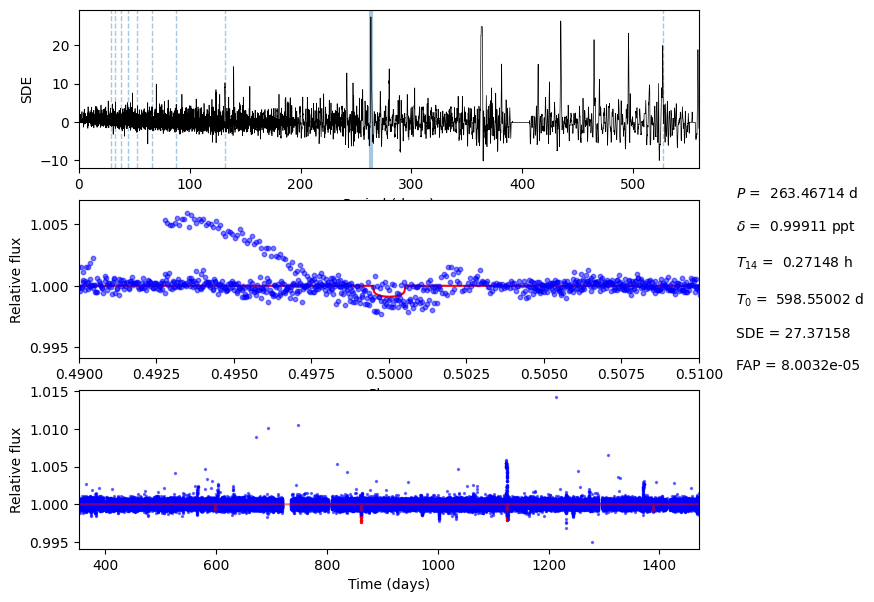

In [88]:
fig, ax = plt.subplots(3, 1, figsize=(8, 7))

ax[0].axvline(results_fourth_run.period, alpha=0.4, lw=3)
plt.xlim(np.min(results_fourth_run.periods), np.max(results_fourth_run.periods))
for n in range(2, 10):
    ax[0].axvline(n*results_fourth_run.period, alpha=0.4, lw=1, linestyle="dashed")
    ax[0].axvline(results_fourth_run.period / n, alpha=0.4, lw=1, linestyle="dashed")
ax[0].set_ylabel(r'SDE')
ax[0].set_xlabel('Period (days)')
ax[0].plot(results_fourth_run.periods, results_fourth_run.power, color='black', lw=0.5)
ax[0].set_xlim(0, max(results_fourth_run.periods));

ax[1].plot(results_fourth_run.model_folded_phase, results_fourth_run.model_folded_model, color='red')
ax[1].scatter(results_fourth_run.folded_phase, results_fourth_run.folded_y, color='blue', s=10, alpha=0.5, zorder=2)
ax[1].set_xlim(0.49, 0.51)
ax[1].set_ylim(min(results_fourth_run.folded_y) - 0.001, 1.007)
ax[1].set_xlabel('Phase')
ax[1].set_ylabel('Relative flux');

intransit = transit_mask(t_fourth_run, results_fourth_run.period, 2 * results_fourth_run.duration, results_fourth_run.T0)

ax[2].scatter(t_fourth_run[intransit], y_fourth_run[intransit], color='red', s=2,zorder=0)
ax[2].scatter(t_fourth_run[~intransit], y_fourth_run[~intransit], color='blue', alpha=0.5, s=2, zorder=0)
ax[2].plot(results_fourth_run.model_lightcurve_time, results_fourth_run.model_lightcurve_model, alpha=0.5, color='red', zorder=1)
ax[1].text(
    1.06,
    0.5,
    f'$P$ = {results_fourth_run.period: .5f} d\n\n' 
    f'$\delta$ = {results_fourth_run.depth: .5f} ppt\n\n'
    '$T_{14}$ = 'f'{results_fourth_run.duration: .5f} h\n\n'
    f'$T_0$ = {results_fourth_run.T0: .5f} d\n\n'
    f'SDE = {results_fourth_run.SDE:.5f}\n\n'
    f'FAP = {results_fourth_run.FAP}',
    transform=ax[1].transAxes,
    va='center'
)

ax[2].set_xlim(min(time), max(time))
# ax[2].ylim(0.9985, 1.0003)
ax[2].set_xlabel('Time (days)')
ax[2].set_ylabel('Relative flux');
# plt.tight_layout()